In [3]:
import json

def fetch_json_data(file_path, output_file_path="cust_data.json"):
    """
    Fetches recipe data from a local JSON file, processes it, and returns only the relevant fields.
    """
    try:
        with open(file_path, 'r') as file:
            data = json.load(file)

        all_recipes = []

        # Iterate over each entry in the JSON file
        for entry in data:
            recipe_info = entry.get("recipe_info", {})
            
            if not recipe_info:
                continue  # Skip if there is no recipe_info

            # Extract delivery date safely
            delivery_date = entry.get("delivery_date", {}).get("$date", None)

            # Extract ingredients and merge with variant ingredients
            ingredients = recipe_info.get("ingredients", [])
            variant_ingredients = []

            # Process the variants if available
            if "variants" in recipe_info:
                variant_ingredients = recipe_info["variants"].get("variant_ingredients", [])

            # Merge ingredients from both the recipe_info and variants
            all_ingredients = list(set(ingredients + variant_ingredients))

            # Prepare the recipe data with only the necessary fields
            recipe = {
                "dish_name": recipe_info.get("dish_name"),
                "meal_category": recipe_info.get("meal_category"),
                "description": recipe_info.get("description"),
                "cuisine": recipe_info.get("cuisine"),
                "ingredients": all_ingredients,  # Merged ingredients
                "allergens_contain": recipe_info.get("allergens_contain", []),
                "meal_type": entry.get("meal_type"),
                "spice_level": recipe_info.get("spice_level", ""),
                "is_auto_select": recipe_info.get("is_auto_select"),
                "delivery_date": delivery_date  # Add extracted date
            }

            # Add the processed recipe data to the list
            all_recipes.append(recipe)

        # If an output file path is provided, save the processed data to that file
        if output_file_path:
            with open(output_file_path, 'w') as output_file:
                json.dump(all_recipes, output_file, indent=4)
            print(f"Processed data saved to {output_file_path}")

        return all_recipes

    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return []
    except json.JSONDecodeError:
        print(f"Error: Failed to decode JSON data in file '{file_path}'. Please check the JSON syntax.")
        return []
    except Exception as e:
        print(f"Error: {str(e)}")
        return []


In [38]:
import os

# List of input file paths
input_file_paths = [
    "user_history/Anita_Nair_deliveries.json",  # Replace with the actual file paths
    "user_history/M K.deliveries.json",  # Replace with the actual file paths
    "user_history/Sonal Rupani.deliveries.json",
    "user_history/Stewart Bell.deliveries.json",  # Replace with the actual file paths
    "user_history/Stewart Bell.deliveries.json",
    "user_history/Yury Panteleev.deliveries.json",

  # Replace with the actual file paths
    # Add more file paths as needed
]

# Define a directory to store output files, or use individual output paths for each file
output_directory = "user_history/processed_files"  # Directory where processed files will be saved

# Ensure output directory exists
if not os.path.exists(output_directory):
    os.makedirs(output_directory)

# Loop through each input file and process it
for input_file_path in input_file_paths:
    # Extract the file name from the input path (e.g., input_file1.json)
    file_name = os.path.basename(input_file_path)
    
    # Define the output file path by combining output directory and the file name
    output_file_path = os.path.join(output_directory, f"processed_{file_name}")
    
    # Call the fetch_json_data function for each file
    processed_data = fetch_json_data(input_file_path, output_file_path)
    
    # Check if the data was successfully processed
    if processed_data:
        print(f"Processed data for {file_name} saved to {output_file_path}")
    else:
        print(f"Failed to process data for {file_name}.")


Processed data saved to user_history/processed_files/processed_Anita_Nair_deliveries.json
Processed data for Anita_Nair_deliveries.json saved to user_history/processed_files/processed_Anita_Nair_deliveries.json
Processed data saved to user_history/processed_files/processed_M K.deliveries.json
Processed data for M K.deliveries.json saved to user_history/processed_files/processed_M K.deliveries.json
Processed data saved to user_history/processed_files/processed_Sonal Rupani.deliveries.json
Processed data for Sonal Rupani.deliveries.json saved to user_history/processed_files/processed_Sonal Rupani.deliveries.json
Processed data saved to user_history/processed_files/processed_Stewart Bell.deliveries.json
Processed data for Stewart Bell.deliveries.json saved to user_history/processed_files/processed_Stewart Bell.deliveries.json
Processed data saved to user_history/processed_files/processed_Stewart Bell.deliveries.json
Processed data for Stewart Bell.deliveries.json saved to user_history/pro

In [31]:
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown


In [41]:
def process_and_analyze_json(file_path, output_file_path="processed_data.json"):
    """
    Fetch, process and analyze the recipe data from a JSON file.
    It will:
    - Extract and merge the ingredients.
    - Analyze top cuisines, spice levels, and user selections.
    - Display visualizations like pie charts.
    """
    try:
        # Fetch and process the data
        recipes = fetch_json_data(file_path, output_file_path)

        # Convert the processed data into a DataFrame
        df = pd.DataFrame(recipes)

        # Identify the top cuisine preference
        top_cuisine = df['cuisine'].mode()[0]
        print(f"Top Cuisine: {top_cuisine}")
        # Identify the user's most preferred spice level
        top_spice_level = df['spice_level'].mode()[0]
        print(f"Top Spice Level: {top_spice_level}")


        # Filter meals that were manually selected by the user (is_auto_select = True)
        user_selected_meals = df[df['is_auto_select'] == True]
        # Display a summary of these user-selected meals
        user_selected_meals_summary = user_selected_meals.describe(include='object')
        # Display the summary in a clean tabular format, similar to df.head()
        print("Summary of User-Selected Meals:")
        display(user_selected_meals_summary)   


        # Filter meals that were manually selected by the user (is_auto_select = True)
        user_selected_meals = df[df['is_auto_select'] == True]
        # Get the most frequent dish names
        top_dish_names = user_selected_meals['dish_name'].value_counts().reset_index()
        # Display the top N dish names (e.g., top 3 dish names)
        top_n = 5
        display(Markdown("### Most Frequently Selected Dishes:"))
        display(top_dish_names.head(top_n))  # Shows top 3 most frequent dish names


        # Filter meals that were manually selected by the user (is_auto_select = True)
        user_selected_meals = df[df['is_auto_select'] == True]
        # Get the count of each cuisine selected by the user
        cuisine_counts = user_selected_meals['cuisine'].value_counts().reset_index()
        # Rename columns for clarity
        cuisine_counts.columns = ["Cuisine", "Count"]
        # Display as a formatted table in Jupyter
        display(Markdown("### Total Cuisine Counts Across all Weeks :"))
        display(cuisine_counts)


        # Set the plot style and remove gridlines
        sns.set(style="darkgrid")
        plt.style.use('dark_background')

        # Create a pie chart with a slightly increased size and transparent background
        plt.figure(figsize=(4, 4))  # Slightly increased pie chart size

        # Plot the pie chart
        plt.pie(
            cuisine_counts['Count'], 
            labels=cuisine_counts['Cuisine'], 
            autopct='%1.1f%%',  # Format for displaying percentages
            colors=sns.color_palette("tab20", len(cuisine_counts)), 
            startangle=90, 
            wedgeprops={'edgecolor': 'none'},  # Remove the border lines between wedges
            labeldistance=1.1,  # Adjusts the label distance from the center to prevent overlap
            pctdistance=0.85  # Distance of the percentage labels from the center
        )

        # Customize font size for the labels and percentage text
        for text in plt.gca().texts:  # Accessing the text labels in the pie chart
            text.set_fontsize(6)  # Set font size for the labels and percentage

        # Customize the plot with smaller font sizes for title and ticks
        plt.title('Cuisines Selected by User', fontsize=8, color='white')  # Smaller title font size
        plt.ylabel('')  # Remove the y-label

        # Make the background transparent
        plt.gcf().patch.set_alpha(0)  # Set the figure background to be transparent

        # Display the plot
        plt.tight_layout()

        # Save the plot with transparent background (if needed)
        # plt.savefig('user_cuisine_pie_chart.png', transparent=True)
        display(Markdown("### Cuisine Preference Across all Weeks :"))
        plt.show()


        # Convert 'delivery_date' to datetime (if it's not already)
        df['delivery_date'] = pd.to_datetime(df['delivery_date'])

        # Find the first and last date to define the week range
        min_date = df['delivery_date'].min()
        max_date = df['delivery_date'].max()

        # Calculate the week number for each record based on 'delivery_date'
        # The first week will be the week containing min_date, and the last week will be the week containing max_date
        df['week_number'] = df['delivery_date'].apply(lambda x: (x - min_date).days // 7 + 1)

        # Step 1: Calculate the count of each cuisine per week
        cuisine_weekly_counts = df.groupby(['week_number', 'cuisine']).size().reset_index(name='count')

        # Step 2: Create a pivot table
        pivot_table = cuisine_weekly_counts.pivot(index="week_number", columns="cuisine", values="count").fillna(0)

        # Step 3: Calculate the total count for each cuisine across all weeks
        cuisine_order = cuisine_weekly_counts.groupby("cuisine")["count"].sum().sort_values()

        # Step 4: Reorder the columns based on the total count of each cuisine
        pivot_table = pivot_table[cuisine_order.index]

        # Step 5: Display the sorted pivot table
        print("Sorted Pivot Table (Cuisine Count by Week):")
        display(Markdown("### Cuisine Preferences over Weeks :"))

        display(pivot_table)


        # Set Seaborn style to none to prevent any background styling
        sns.set(style="ticks")  # Minimal styling with no background

        # Create figure and axis
        fig, ax = plt.subplots(figsize=(4, 2))

        # Plot the bar chart with very thin bars
        pivot_table.plot(
            kind="bar",
            width=0.1,  # Extremely thin bars
            stacked=True,
            colormap="viridis",
            edgecolor="none",
            ax=ax
        )

        # Set the figure background to white
        fig.patch.set_facecolor('white')  # White background for the entire figure
        ax.set_facecolor('white')  # White background for the plot area

        # Remove gridlines & spines
        ax.grid(False)  # No gridlines
        for spine in ax.spines.values():
            spine.set_visible(False)  # Hide the spines

        # Customize labels with black text
        ax.set_xlabel("Week Number", fontsize=8, fontweight="light", color="black")
        ax.set_ylabel("Total Count", fontsize=8, fontweight="light", color="black")
        ax.set_title("Cuisine Preferences Over Weeks", fontsize=10, fontweight="bold", color="black")

        # Reduce font size and move legend outside
        ax.legend(title="Cuisine", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, frameon=False)
        plt.xticks(fontsize=8, rotation=45, color="black")
        plt.yticks(fontsize=8, color="black")

        # Make sure the background is white for the entire figure and plot area
        plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)
        plt.savefig("white_background_chart.png", facecolor='white', transparent=False)

        # Show the plot
        plt.show()


        return df  # Return the DataFrame if needed

    except FileNotFoundError:
        print(f"Error: The file '{file_path}' was not found.")
        return []
    except json.JSONDecodeError:
        print(f"Error: Failed to decode JSON data in file '{file_path}'. Please check the JSON syntax.")
        return []
    except Exception as e:
        print(f"Error: {str(e)}")
        return []

### **User 1**

Processed data saved to user_history/processed_files/processed_Anita_Nair_deliveries.json
Top Cuisine: Mediterranean
Top Spice Level: Low
Summary of User-Selected Meals:


,dish_name,meal_category,description,cuisine,ingredients,allergens_contain,meal_type,spice_level,delivery_date
count,95,95,95,95,95,95,95,95,95
unique,83,3,85,9,88,33,5,2,25
top,Raspberry Yoghurt,Snack,"Fluffy omelette with cheddar, fresh broccoli &...",Mediterranean,"[Water, Egg, Mozzarella Cheese, Cheddar Cheese...",[],morning_snack,Low,2025-01-31T00:00:00.000Z
freq,2,39,2,34,2,46,22,58,5


### Most Frequently Selected Dishes:

,dish_name,count
0,Raspberry Yoghurt,2
1,Chocolate Muffin,2
2,Cheesy Omelette with Broccoli,2
3,Cajun Protein with Spinach,2
4,Chicken a la King & Onion Bread Roll,2


### Total Cuisine Counts Across all Weeks :

,Cuisine,Count
0,Mediterranean,34
1,European,21
2,Comfort Food,18
3,American,5
4,Arabic,5
5,South American,4
6,Fusion,4
7,Asian,3
8,Indian,1


### Cuisine Preference Across all Weeks :

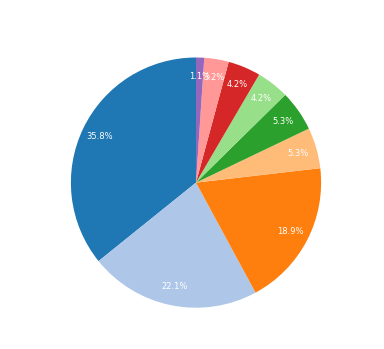

Sorted Pivot Table (Cuisine Count by Week):


### Cuisine Preferences over Weeks :

cuisine,Indian,Fusion,South American,American,Asian,Arabic,Comfort Food,European,Mediterranean
week_number,,,,,,,,,
1,2.0,0.0,1.0,1.0,1.0,2.0,3.0,5.0,10.0
2,0.0,0.0,0.0,0.0,3.0,2.0,2.0,11.0,7.0
3,0.0,2.0,1.0,0.0,0.0,2.0,5.0,6.0,9.0
4,0.0,0.0,1.0,2.0,0.0,1.0,3.0,0.0,3.0
5,1.0,1.0,0.0,0.0,2.0,2.0,3.0,7.0,9.0
6,0.0,1.0,1.0,1.0,3.0,0.0,6.0,6.0,7.0
7,0.0,2.0,2.0,3.0,1.0,1.0,7.0,5.0,4.0
8,1.0,0.0,0.0,1.0,0.0,1.0,2.0,3.0,12.0


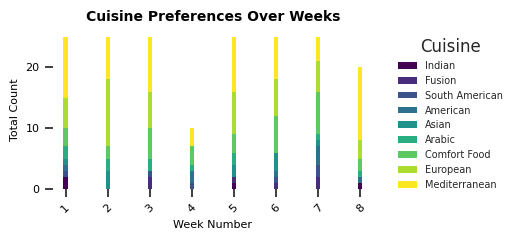

In [42]:
# For File 1
df1 = process_and_analyze_json("user_history/Anita_Nair_deliveries.json", "user_history/processed_files/processed_Anita_Nair_deliveries.json")


In [ ]:

# For File 2
df2 = process_and_analyze_json("user_history/M K.deliveries.json", "user_history/processed_files/processed_M K.deliveries.json")

# For File 3
df3 = process_and_analyze_json("user_history/Sonal Rupani.deliveries.json", "user_history/processed_files/processed_Sonal Rupani.deliveries.json")


### **User 2**

Processed data saved to user_history/processed_files/processed_M K.deliveries.json
Top Cuisine: Mediterranean
Top Spice Level: Low
Summary of User-Selected Meals:


,dish_name,meal_category,description,cuisine,ingredients,allergens_contain,meal_type,spice_level,delivery_date
count,120,120,120,120,120,120,120,120,120
unique,102,3,106,9,107,67,5,2,24
top,Classic Chicken Salad,Meal,"With celery, onions & lemon. Dairy & Gluten Free.",Mediterranean,[Grapes],[],lunch,Low,2025-03-05T00:00:00.000Z
freq,3,48,3,45,3,14,24,67,5


### Most Frequently Selected Dishes:

,dish_name,count
0,Classic Chicken Salad,3
1,Grapes Pot,3
2,Chimichurri Steak,2
3,Lentil Curry & Almond Black Rice,2
4,Chocolate Raspberry Mousse,2


### Total Cuisine Counts Across all Weeks :

,Cuisine,Count
0,Mediterranean,45
1,European,33
2,Comfort Food,17
3,American,9
4,Arabic,6
5,Fusion,5
6,Asian,2
7,Indian,2
8,South American,1


### Cuisine Preference Across all Weeks :

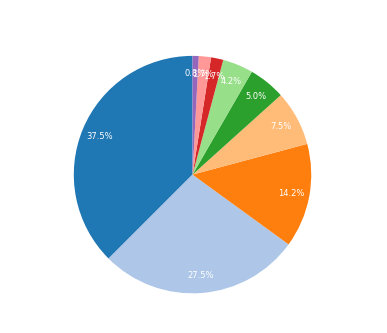

Sorted Pivot Table (Cuisine Count by Week):


### Cuisine Preferences over Weeks :

cuisine,South American,Asian,Indian,Fusion,Arabic,American,Comfort Food,European,Mediterranean
week_number,,,,,,,,,
1,0.0,0.0,2.0,2.0,1.0,4.0,4.0,8.0,9.0
2,0.0,1.0,0.0,2.0,2.0,2.0,4.0,10.0,9.0
3,0.0,0.0,0.0,0.0,1.0,1.0,3.0,2.0,8.0
4,1.0,1.0,0.0,0.0,1.0,1.0,5.0,9.0,12.0
5,0.0,0.0,0.0,1.0,1.0,1.0,1.0,4.0,7.0


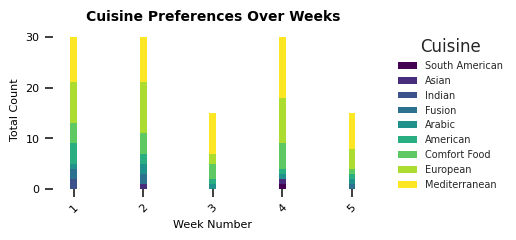

In [43]:
df2 = process_and_analyze_json("user_history/M K.deliveries.json", "user_history/processed_files/processed_M K.deliveries.json")


### **User 3**

Processed data saved to user_history/processed_files/processed_Sonal Rupani.deliveries.json
Top Cuisine: Mediterranean
Top Spice Level: Medium
Summary of User-Selected Meals:


,dish_name,meal_category,description,cuisine,ingredients,allergens_contain,meal_type,spice_level,delivery_date
count,80,80,80,80,80,80,80,80,80
unique,68,3,70,8,71,54,5,2,20
top,Parmesan Soufflé,Snack,"With celery, onions & lemon. Dairy & Gluten Free.",Mediterranean,"[Dijon Mustard, Romaine Lettuce, Onion Powder,...",[Dairy],lunch,Medium,2025-02-14T00:00:00.000Z
freq,2,33,2,35,2,9,18,44,5


### Most Frequently Selected Dishes:

,dish_name,count
0,Parmesan Soufflé,2
1,Salted Almond,2
2,Mini Quiches,2
3,Tuna Salad,2
4,Chicken Crunchy Bowl,2


### Total Cuisine Counts Across all Weeks :

,Cuisine,Count
0,Mediterranean,35
1,European,23
2,Comfort Food,7
3,American,4
4,Fusion,4
5,Indian,3
6,Asian,2
7,Arabic,2


### Cuisine Preference Across all Weeks :

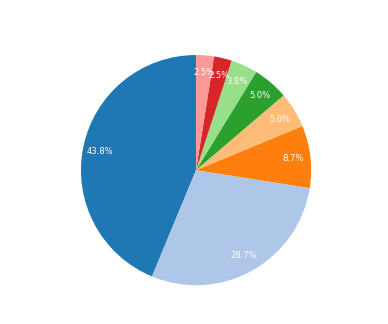

Sorted Pivot Table (Cuisine Count by Week):


### Cuisine Preferences over Weeks :

cuisine,Asian,Arabic,Indian,Fusion,American,Comfort Food,European,Mediterranean
week_number,,,,,,,,
1,0.0,1.0,1.0,2.0,2.0,0.0,4.0,15.0
2,0.0,2.0,0.0,1.0,2.0,1.0,12.0,7.0
3,1.0,0.0,1.0,1.0,1.0,5.0,3.0,8.0
4,1.0,0.0,1.0,0.0,1.0,2.0,6.0,14.0
5,0.0,0.0,0.0,0.0,0.0,0.0,2.0,3.0


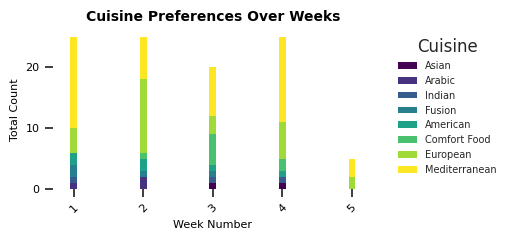

In [44]:
df3 = process_and_analyze_json("user_history/Sonal Rupani.deliveries.json", "user_history/processed_files/processed_Sonal Rupani.deliveries.json")


### **User 4**

Processed data saved to user_history/processed_files/processed_Stewart Bell.deliveries.json
Top Cuisine: Mediterranean
Top Spice Level: Low
Summary of User-Selected Meals:


,dish_name,meal_category,description,cuisine,ingredients,allergens_contain,meal_type,spice_level,delivery_date
count,109,109,109,109,109,109,109,109,109
unique,80,3,80,8,91,51,5,3,30
top,Greek Yogurt,Meal,Topped with peaches & amaretti biscuits. Conta...,Mediterranean,"[Stevia, Almond, Mango, Almond Milk, Honey, Pi...",[Dairy],lunch,Low,2025-03-04T00:00:00.000Z
freq,4,52,4,45,4,13,28,65,5


### Most Frequently Selected Dishes:

,dish_name,count
0,Greek Yogurt,4
1,Dates & Mango Bircher Muesli,4
2,Yoghurt Granola,4
3,Kalamata Olives & Parmesan Cheese,3
4,Sticky Mango & Coconut Rice Pudding,2


### Total Cuisine Counts Across all Weeks :

,Cuisine,Count
0,Mediterranean,45
1,European,19
2,American,14
3,Comfort Food,14
4,Arabic,8
5,Fusion,5
6,Asian,3
7,Indian,1


### Cuisine Preference Across all Weeks :

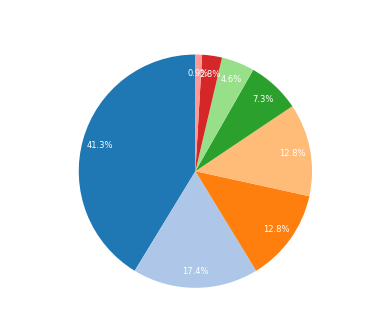

Sorted Pivot Table (Cuisine Count by Week):


### Cuisine Preferences over Weeks :

cuisine,Indian,Asian,Fusion,Arabic,American,Comfort Food,European,Mediterranean
week_number,,,,,,,,
1,1.0,0.0,1.0,2.0,4.0,4.0,2.0,11.0
2,0.0,1.0,2.0,2.0,4.0,3.0,4.0,9.0
3,0.0,1.0,1.0,1.0,0.0,8.0,4.0,10.0
4,0.0,0.0,0.0,1.0,0.0,6.0,9.0,9.0
5,0.0,0.0,0.0,1.0,7.0,4.0,5.0,8.0
6,0.0,2.0,2.0,3.0,0.0,2.0,8.0,8.0


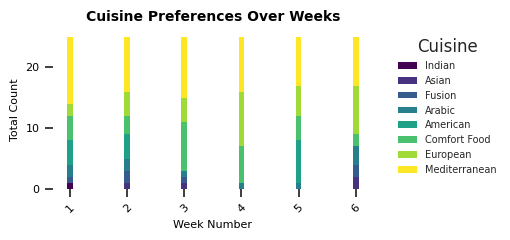

In [46]:
df4 = process_and_analyze_json("user_history/Stewart Bell.deliveries.json", "user_history/processed_files/processed_Stewart Bell.deliveries.json")


### **User 5**

Processed data saved to user_history/processed_files/processed_Yury Panteleev.deliveries.json
Top Cuisine: European
Top Spice Level: Low
Summary of User-Selected Meals:


,dish_name,meal_category,description,cuisine,ingredients,allergens_contain,meal_type,spice_level,delivery_date
count,92,92,92,92,92,92,92,92,92
unique,71,3,71,7,81,48,5,2,28
top,Grapes Pot,Snack,Fresh seasonal grapes. Dairy & Gluten Free.,Mediterranean,[Grapes],[],breakfast,Low,2025-03-10T00:00:00.000Z
freq,3,37,3,37,3,9,24,57,5


### Most Frequently Selected Dishes:

,dish_name,count
0,Grapes Pot,3
1,Chocolate Raspberry Mousse,2
2,Dates & Mango Bircher Muesli,2
3,Omega Egg with Parmesan & Pesto,2
4,Tomato Basil Soup,2


### Total Cuisine Counts Across all Weeks :

,Cuisine,Count
0,Mediterranean,37
1,European,29
2,Comfort Food,9
3,American,8
4,Fusion,4
5,Arabic,3
6,Asian,2


### Cuisine Preference Across all Weeks :

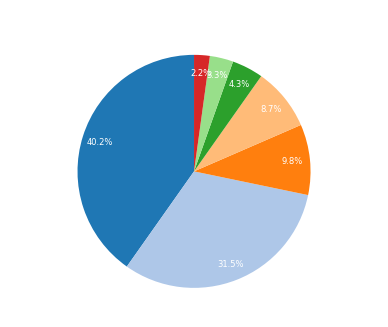

Sorted Pivot Table (Cuisine Count by Week):


### Cuisine Preferences over Weeks :

cuisine,Asian,South American,Arabic,Fusion,American,Comfort Food,Mediterranean,European
week_number,,,,,,,,
1,0.0,0.0,0.0,0.0,4.0,2.0,10.0,9.0
2,1.0,0.0,0.0,1.0,1.0,1.0,6.0,10.0
3,1.0,2.0,1.0,3.0,0.0,7.0,6.0,5.0
4,0.0,1.0,1.0,0.0,1.0,3.0,9.0,5.0
5,0.0,0.0,1.0,0.0,7.0,0.0,9.0,8.0
6,1.0,0.0,1.0,2.0,2.0,3.0,6.0,10.0


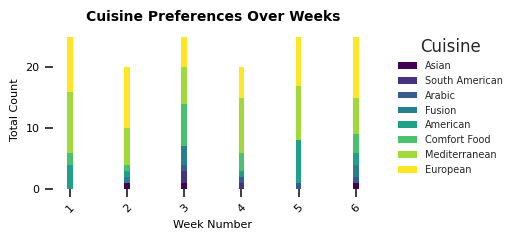

In [47]:
df4 = process_and_analyze_json("user_history/Yury Panteleev.deliveries.json", "user_history/processed_files/processed_Yury Panteleev.deliveries.json")
